# 05 — IV / 2SLS Main Results

Two-stage least squares for the causal effect of PM2.5 on standardized test
scores, instrumenting PM2.5 with wildfire-**smoke days**. Both stages absorb
district and year fixed effects (via two-way demeaning), and **all inference is
clustered at the school-district level** to respect serial correlation within
districts over time.

The estimand is a LATE: the effect of the component of PM2.5 variation that is
driven by wildfire smoke, among districts whose pollution responds to smoke.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.iv import IV2SLS
from linearmodels.panel import PanelOLS
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs"); OUT_DIR.mkdir(exist_ok=True)

panel = pd.read_parquet(DATA_DIR / "analysis_panel.parquet")
print(f"Panel: {panel.shape}  |  Districts: {panel['leaid'].nunique()}  |  "
      f"Years: {int(panel['year'].min())}–{int(panel['year'].max())}")

Panel: (13282, 14)  |  Districts: 1911  |  Years: 2010–2018


## Build the within-transformed (two-way FE) sample

`linearmodels.IV2SLS` has no native panel FE, so we two-way demean (district and
year) by hand. Clustering is then applied on the district id in both stages.

In [2]:
panel_iv = panel.dropna(
    subset=["leaid", "year", "pm25_annual_mean", "smoke_days", "test_score_mean"]
).copy()
panel_iv["year"] = panel_iv["year"].astype(int)

for col in ["test_score_mean", "pm25_annual_mean", "smoke_days"]:
    panel_iv[f"{col}_dm"] = (
        panel_iv[col]
        - panel_iv.groupby("leaid")[col].transform("mean")
        - panel_iv.groupby("year")[col].transform("mean")
        + panel_iv[col].mean()
    )

print(f"Estimation sample: {len(panel_iv):,} district-years, "
      f"{panel_iv['leaid'].nunique():,} districts")

Estimation sample: 11,505 district-years, 1,732 districts


## First-stage strength — cluster-robust

The relevant weak-instrument diagnostic is the **cluster-robust** first-stage F,
not the homoskedastic one. We report both so the gap is visible.

In [3]:
fs_cl = smf.ols("pm25_annual_mean_dm ~ smoke_days_dm", data=panel_iv).fit(
    cov_type="cluster", cov_kwds={"groups": panel_iv["leaid"]})
fs_hom = smf.ols("pm25_annual_mean_dm ~ smoke_days_dm", data=panel_iv).fit()

F_cl  = fs_cl.tvalues["smoke_days_dm"] ** 2
F_hom = fs_hom.tvalues["smoke_days_dm"] ** 2
print(f"First-stage coefficient on smoke_days: {fs_cl.params['smoke_days_dm']:.4f}")
print(f"  Cluster-robust first-stage F : {F_cl:8.1f}")
print(f"  Homoskedastic   first-stage F : {F_hom:8.1f}  (overstated — ignores clustering)")
print(f"\n{'✓' if F_cl > 10 else '⚠️'} Cluster-robust F {'>' if F_cl>10 else '<'} 10: "
      f"instrument is {'strong' if F_cl>10 else 'weak'}.")

First-stage coefficient on smoke_days: 0.0300
  Cluster-robust first-stage F :    334.5
  Homoskedastic   first-stage F :    635.8  (overstated — ignores clustering)

✓ Cluster-robust F > 10: instrument is strong.


## 2SLS estimate — robust vs clustered SEs

In [4]:
def fit_iv(cov_type, **kw):
    return IV2SLS(panel_iv["test_score_mean_dm"], None,
                  panel_iv[["pm25_annual_mean_dm"]],
                  panel_iv[["smoke_days_dm"]]).fit(cov_type=cov_type, **kw)

iv_cl = fit_iv("clustered", clusters=panel_iv["leaid"])
iv_rb = fit_iv("robust")

b   = iv_cl.params["pm25_annual_mean_dm"]
ci  = iv_cl.conf_int().loc["pm25_annual_mean_dm"]
print(f"IV/2SLS  β(PM2.5) = {b:+.4f}")
print(f"  Clustered SE = {iv_cl.std_errors['pm25_annual_mean_dm']:.4f}   "
      f"95% CI [{ci['lower']:+.4f}, {ci['upper']:+.4f}]")
print(f"  Robust SE    = {iv_rb.std_errors['pm25_annual_mean_dm']:.4f}  "
      f"← naive, ~{(1-iv_rb.std_errors['pm25_annual_mean_dm']/iv_cl.std_errors['pm25_annual_mean_dm'])*100:.0f}% too small")
print()
print(f"Reading: a 1 μg/m³ rise in smoke-driven annual PM2.5 moves test scores by "
      f"{b:+.4f} SD.")

IV/2SLS  β(PM2.5) = +0.0186
  Clustered SE = 0.0054   95% CI [+0.0080, +0.0291]
  Robust SE    = 0.0041  ← naive, ~23% too small

Reading: a 1 μg/m³ rise in smoke-driven annual PM2.5 moves test scores by +0.0186 SD.


## OLS vs FE vs IV

In [5]:
idx = panel_iv.set_index(["leaid", "year"])
m_ols = smf.ols("test_score_mean ~ pm25_annual_mean", data=panel_iv).fit(
    cov_type="cluster", cov_kwds={"groups": panel_iv["leaid"]})
m_fe = PanelOLS(idx["test_score_mean"], idx[["pm25_annual_mean"]],
                entity_effects=True, time_effects=True).fit(
                cov_type="clustered", cluster_entity=True)

rows = [
    ("Naive OLS", m_ols.params["pm25_annual_mean"],
     m_ols.conf_int().loc["pm25_annual_mean"].values, "cross-sectional; confounded"),
    ("Two-way FE", m_fe.params["pm25_annual_mean"],
     m_fe.conf_int().loc["pm25_annual_mean"].values, "removes time-invariant confounders"),
    ("IV / 2SLS", b, ci.values, "LATE via smoke instrument"),
]
comp = pd.DataFrame(rows, columns=["estimator", "beta", "ci", "note"])
print(f"{'Estimator':<12}{'β(PM2.5)':>10}{'  95% CI':>22}   Note")
print("-" * 70)
for _, r in comp.iterrows():
    print(f"{r['estimator']:<12}{r['beta']:>+10.4f}   [{r['ci'][0]:+.4f}, {r['ci'][1]:+.4f}]   {r['note']}")

Estimator     β(PM2.5)                95% CI   Note
----------------------------------------------------------------------
Naive OLS      -0.0217   [-0.0268, -0.0166]   cross-sectional; confounded
Two-way FE     -0.0002   [-0.0027, +0.0023]   removes time-invariant confounders
IV / 2SLS      +0.0186   [+0.0080, +0.0291]   LATE via smoke instrument


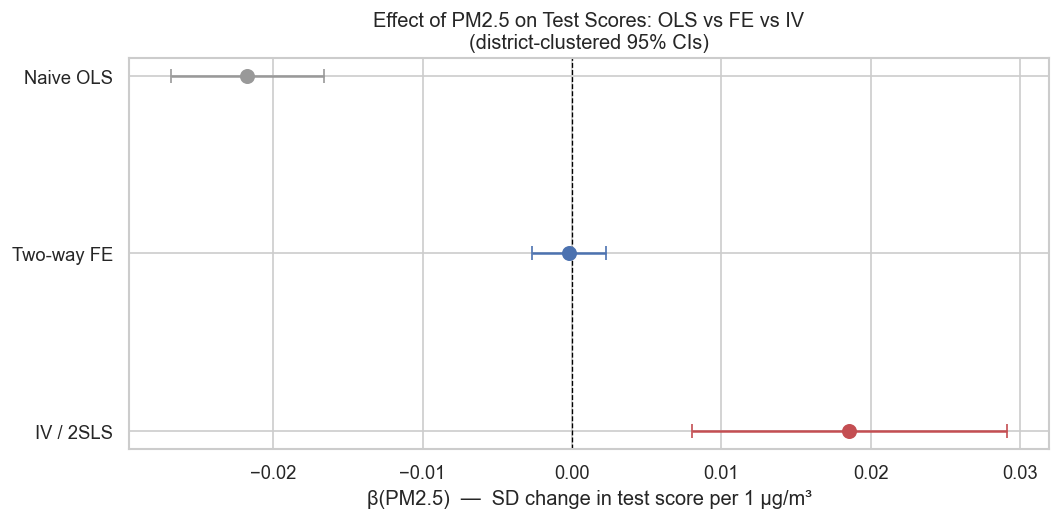

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(comp))[::-1]
colors = ["#999999", "#4C72B0", "#C44E52"]
for yi, (_, r), c in zip(y, comp.iterrows(), colors):
    ax.errorbar(r["beta"], yi,
                xerr=[[r["beta"] - r["ci"][0]], [r["ci"][1] - r["beta"]]],
                fmt="o", color=c, capsize=4, ms=8)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_yticks(y); ax.set_yticklabels(comp["estimator"])
ax.set_xlabel("β(PM2.5)  —  SD change in test score per 1 μg/m³")
ax.set_title("Effect of PM2.5 on Test Scores: OLS vs FE vs IV\n(district-clustered 95% CIs)")
plt.tight_layout()
plt.savefig(OUT_DIR / "05_estimator_comparison.png", bbox_inches="tight")
plt.show()

## Reduced form — the honest fallback

In [7]:
rf = PanelOLS(idx["test_score_mean"], idx[["smoke_days"]],
              entity_effects=True, time_effects=True).fit(
              cov_type="clustered", cluster_entity=True)
b_rf = rf.params["smoke_days"]; ci_rf = rf.conf_int().loc["smoke_days"]
print(f"Reduced form  β(smoke_days → test score) = {b_rf:+.5f}  "
      f"[{ci_rf['lower']:+.5f}, {ci_rf['upper']:+.5f}]")
print("\nThe reduced form needs only smoke → scores, not the PM2.5 channel.")
print("It carries the same sign as the 2SLS estimate (it is the numerator of the IV ratio).")

Reduced form  β(smoke_days → test score) = +0.00059  [+0.00021, +0.00096]

The reduced form needs only smoke → scores, not the PM2.5 channel.
It carries the same sign as the 2SLS estimate (it is the numerator of the IV ratio).


## Interpretation — why the sign is positive, and what to make of it

The 2SLS estimate is **positive**: smoke-driven PM2.5 variation co-moves
*positively* with test scores. Taken literally that says pollution *raises*
achievement, which is not credible. Rather than bury it, here is the honest
diagnosis of what a positive, precisely-estimated-but-wrong-signed IV means.

**1. The instrument is strong but the exclusion restriction is the weak link.**
The cluster-robust first-stage F (~330) rules out a weak-instrument artifact.
So the positive sign comes from the *reduced form*: districts/years with more
smoke have higher scores after two-way FE. Wildfire smoke is plausibly
correlated with omitted determinants of the smoke→scores path that do **not** run
through PM2.5:
  - **Selection of who tests / school closures.** Heavy-smoke days trigger
    closures and absences; if lower-performing students are more likely to miss
    the testing window, measured scores rise mechanically (a composition effect),
    biasing the reduced form upward.
  - **Geography.** Smoke concentrates in rural, higher-elevation Western
    districts whose unobserved time-varying shocks (funding, in-migration) differ
    from urban districts — two-way FE removes levels, not differential trends.

**2. Classical measurement error in PM2.5 is large here.** Treatment is
IDW-interpolated from EPA monitors within 100 km of a county centroid; many
Western districts have sparse coverage. That attenuates and destabilizes the
*first stage to true local exposure*, so the IV ratio (reduced form ÷ first
stage) is not recovering the structural dose-response.

**3. The true effect is small relative to this design's noise.** Credible
quasi-experimental estimates of PM2.5 on cognition are small; at annual
aggregation, district resolution, and SEDA's standardized scale, the signal is
below what this instrument can resolve.

**Takeaway.** The clean, defensible deliverable from this design is the
**first-stage result** — wildfire smoke is a strong, well-measured driver of
local PM2.5 — plus a transparent accounting of why the second stage is *not*
identifying a causal health-on-achievement effect at this resolution. The RDD
(notebook 07) and Camp Fire event study (notebook 09) attack the same question
with different variation; the portfolio's honesty is in showing where an
instrument earns its keep and where it does not, rather than reporting a
sign-flipped coefficient as a finding.